<a href="https://colab.research.google.com/github/Minh-Khuong/Bai-tap-Ai-tuan-1-Vu-Minh-Khuong-31251020110/blob/Bai-Tap-AI-Tuan-1/Bai%20tap%20AI-Tuan%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
#23.1
import folium
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="bai_23_1", timeout=10)
truong_hoc = geolocator.geocode("Đại học Kinh tế, TP.HCM")
center_coords = (truong_hoc.latitude, truong_hoc.longitude)
m = folium.Map(location=center_coords, zoom_start=15)
folium.Marker(center_coords, popup="UEH", icon=folium.Icon(color="red")).add_to(m)
dia_diem_lan_can = ["Bệnh viện Từ Dũ", "Chợ Bến Thành", "Dinh Độc Lập", "Nhà văn hóa Thanh Niên"]
for ten in dia_diem_lan_can:
    loc = geolocator.geocode(ten + ", TP.HCM")
    if loc:
        folium.Marker((loc.latitude, loc.longitude), popup=ten, icon=folium.Icon(color="blue")).add_to(m)
display(m)

In [4]:
#23.2
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="bai_23_2", timeout=10)
diem_goc = geolocator.geocode("Đại học Kinh tế, TP.HCM")
toado_goc = (diem_goc.latitude, diem_goc.longitude)

m = folium.Map(location=toado_goc, zoom_start=13)
folium.Marker(toado_goc, popup="Điểm xuất phát (UEH)", icon=folium.Icon(color="red")).add_to(m)
danh_sach_den = ["Landmark 81", "Sân bay Tân Sơn Nhất", "Thảo Cầm Viên"]

for ten in danh_sach_den:
    loc = geolocator.geocode(ten + ", TP.HCM")
    if loc:
        toado_den = (loc.latitude, loc.longitude)
        khoang_cach = geodesic(toado_goc, toado_den).km
        folium.Marker(toado_den, popup=f"{ten} ({khoang_cach:.2f} km)").add_to(m)
        folium.PolyLine([toado_goc, toado_den], color="green", weight=3).add_to(m)

display(m)

In [13]:
#23.3
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[10.7325, 106.7145], zoom_start=14)

data = [
    [10.7325, 106.7145, 0.9], [10.7310, 106.7150, 0.8], [10.7330, 106.7130, 0.9],
    [10.7350, 106.7100, 0.7], [10.7300, 106.7200, 0.6], [10.7400, 106.7050, 0.5],
    [10.7250, 106.7250, 0.4], [10.7450, 106.7000, 0.3], [10.7200, 106.7300, 0.2]
]

HeatMap(data, radius=25, blur=15).add_to(m)
folium.LayerControl().add_to(m)

display(m)

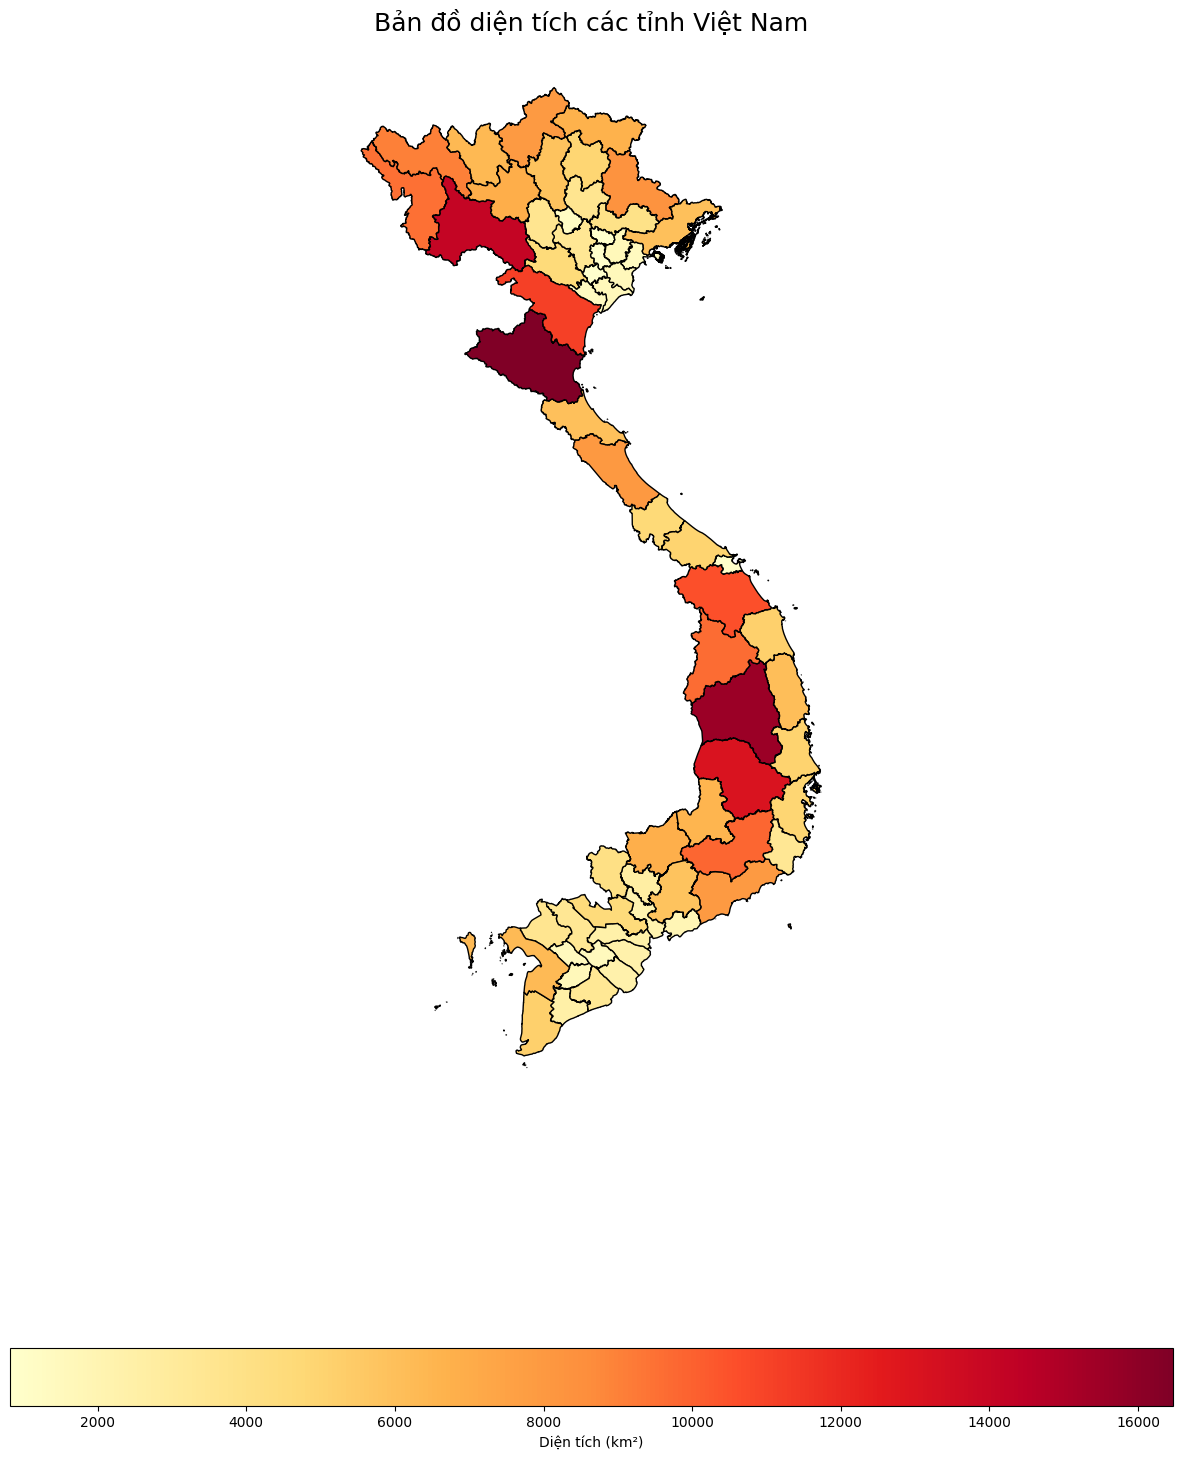

In [10]:
# 23.4
import geopandas as gpd
import matplotlib.pyplot as plt
vietnam = gpd.read_file("/content/gadm41_VNM_1.json")
vietnam = vietnam.to_crs(epsg=3405)
vietnam['dien_tich_km2'] = vietnam['geometry'].area / 10**6
fig, ax = plt.subplots(figsize=(15, 20))
vietnam.plot(
    column='dien_tich_km2',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': "Diện tích (km²)",
        'orientation': "horizontal"
    }
)
plt.title("Bản đồ diện tích các tỉnh Việt Nam", fontsize=18)
ax.set_axis_off()
plt.show()

In [6]:
# 23.5
import folium
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="bai_23_5")
loc = geolocator.geocode("Đại học Kinh tế, TP.HCM")
toa_do_kho = [loc.latitude, loc.longitude]
m = folium.Map(location=toa_do_kho, zoom_start=13)
folium.Marker(toa_do_kho, popup="Đại học Kinh tế (UEH)", icon=folium.Icon(color="red")).add_to(m)
folium.Circle(toa_do_kho, radius=1000, color="green", fill=True, tooltip="Giao siêu tốc (1km)").add_to(m)
folium.Circle(toa_do_kho, radius=3000, color="blue", fill=False, tooltip="Giao tiêu chuẩn (3km)").add_to(m)
folium.Circle(toa_do_kho, radius=5000, color="orange", fill=False, tooltip="Giao chậm (5km)").add_to(m)
display(m)

Khu vực: Chợ Bến Thành, Quận 1, TP.HCM
Số lượng nút giao: 380
Chiều dài đường trung bình: 91.08 mét


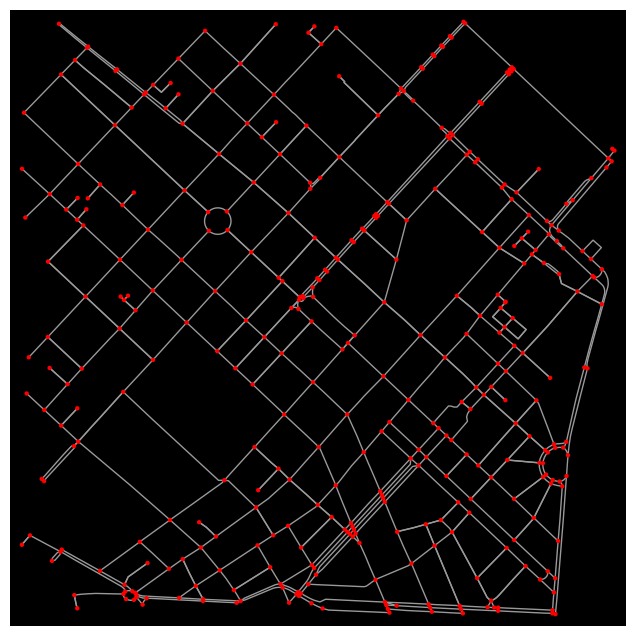

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [33]:
#23.6
import osmnx as ox

ten_dia_diem = "Chợ Bến Thành, Quận 1, TP.HCM"
graph = ox.graph_from_address(ten_dia_diem, dist=1000, network_type='drive')

stats = ox.basic_stats(graph)

print(f"Khu vực: {ten_dia_diem}")
print(f"Số lượng nút giao: {stats['n']}")
print(f"Chiều dài đường trung bình: {stats['edge_length_avg']:.2f} mét")

ox.plot_graph(graph, node_size=10, node_color='red', bgcolor='black')

In [31]:
#23.7
import osmnx as ox
import networkx as nx
import folium

diem_a = ox.geocode("Đại học Kinh tế, TP.HCM")
diem_b = ox.geocode("Vạn Hạnh Mall, TP.HCM")

G = ox.graph_from_point(diem_a, dist=1000, network_type='drive')

start = ox.distance.nearest_nodes(G, diem_a[1], diem_a[0])
end = ox.distance.nearest_nodes(G, diem_b[1], diem_b[0])

duong_dijkstra = nx.dijkstra_path(G, start, end, weight='length')

def khoang_cach(u, v):
    return ox.distance.euclidean(G.nodes[u]['y'], G.nodes[u]['x'], G.nodes[v]['y'], G.nodes[v]['x'])

duong_astar = nx.astar_path(G, start, end, heuristic=khoang_cach, weight='length')

m = folium.Map(location=diem_a, zoom_start=15)

toa_do_1 = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in duong_dijkstra]
toa_do_2 = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in duong_astar]

folium.PolyLine(toa_do_1, color="blue", weight=8).add_to(m)
folium.PolyLine(toa_do_2, color="red", weight=3).add_to(m)

display(m)

Chiều dài thuật toán Dijkstra: 1319 mét
Chiều dài thuật toán A*: 1319 mét


In [37]:
#23.10
import osmnx as ox
import networkx as nx
import folium
from geopy.distance import geodesic

diem_a = ox.geocode("Thảo Cầm Viên, TP.HCM")
diem_b = ox.geocode("Đại học Kinh tế, TP.HCM")
diem_ket = ox.geocode("Dinh Độc Lập, TP.HCM")

G = ox.graph_from_point(diem_ket, dist=3500, network_type='drive')

start = ox.distance.nearest_nodes(G, diem_a[1], diem_a[0])
end = ox.distance.nearest_nodes(G, diem_b[1], diem_b[0])

duong_thuong = nx.shortest_path(G, start, end, weight='length')

G_moi = G.copy()
for u, v, data in G_moi.edges(data=True):
    pos = (G_moi.nodes[u]['y'], G_moi.nodes[u]['x'])
    if geodesic(pos, diem_ket).meters < 400:
        data['length'] *= 100

duong_tranh = nx.shortest_path(G_moi, start, end, weight='length')

m = folium.Map(location=diem_ket, zoom_start=14)
folium.Circle(diem_ket, radius=400, color='red', fill=True).add_to(m)

toa_do_1 = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in duong_thuong]
toa_do_2 = [(G_moi.nodes[n]['y'], G_moi.nodes[n]['x']) for n in duong_tranh]

folium.PolyLine(toa_do_1, color='red', weight=3, dash_array='5').add_to(m)
folium.PolyLine(toa_do_2, color='green', weight=6).add_to(m)

folium.Marker(diem_a, popup="Thảo Cầm Viên", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(diem_b, popup="Đại học Kinh tế", icon=folium.Icon(color="blue")).add_to(m)
folium.Marker(diem_ket, popup="Dinh Độc Lập", icon=folium.Icon(color="orange")).add_to(m)

display(m)

In [40]:
#23.11
import folium
import osmnx as ox
danh_sach = [
    ("Phố đi bộ Nguyễn Huệ, TP.HCM", "Rất cao (Thiếu xe)", "red"),
    ("Thảo Cầm Viên, TP.HCM", "Trung bình (Ổn định)", "orange"),
    ("Chợ Bến Thành, TP.HCM", "Thấp (Dư xe)", "green")
]
tam_ban_do = ox.geocode("Nhà hát Thành phố, TP.HCM")
m = folium.Map(location=tam_ban_do, zoom_start=14)

for ten, trang_thai, mau in danh_sach:
    toa_do = ox.geocode(ten)
    folium.Circle(
        location=toa_do,
        radius=400,
        color=mau,
        fill=True,
        popup=f"{ten} - {trang_thai}"
    ).add_to(m)
    folium.Marker(
        location=toa_do,
        icon=folium.Icon(color=mau)
    ).add_to(m)
display(m)

In [44]:
#23.12
import osmnx as ox
import folium
from geopy.distance import geodesic

kho_1 = ox.geocode("Chợ Bến Thành, TP.HCM")
kho_2 = ox.geocode("Hồ Con Rùa, TP.HCM")

khach_1 = [ox.geocode("Bảo tàng Mỹ thuật, TP.HCM"), ox.geocode("Phố đi bộ Nguyễn Huệ, TP.HCM")]
khach_2 = [ox.geocode("Nhà văn hóa Thanh Niên, TP.HCM"), ox.geocode("Diamond Plaza, TP.HCM")]

m = folium.Map(location=kho_1, zoom_start=14)
folium.Marker(kho_1, icon=folium.Icon(color='red')).add_to(m)
folium.Marker(kho_2, icon=folium.Icon(color='red')).add_to(m)

danh_sach_kho = [(kho_1, khach_1, 'purple'), (kho_2, khach_2, 'green')]
tong_kc = 0

for kho, khach, mau in danh_sach_kho:
    diem_ht = kho
    lo_trinh = [kho]

    while khach:
        diem_gan = min(khach, key=lambda x: geodesic(diem_ht, x).meters)
        tong_kc += geodesic(diem_ht, diem_gan).meters
        lo_trinh.append(diem_gan)
        khach.remove(diem_gan)
        diem_ht = diem_gan
        folium.Marker(diem_gan, icon=folium.Icon(color='blue')).add_to(m)

    tong_kc += geodesic(diem_ht, kho).meters
    lo_trinh.append(kho)
    folium.PolyLine(lo_trinh, color=mau, weight=4).add_to(m)

print(f"Tổng quãng đường Heuristic: {tong_kc:.0f} mét. Giúp tối ưu hóa và chống đi trùng đường.")
display(m)

Tổng quãng đường Heuristic: 2144 mét. Giúp tối ưu hóa và chống đi trùng đường.


In [49]:
#23.13
import folium
import osmnx as ox

diem_a = ox.geocode("Chợ Bến Thành, TP.HCM")
diem_b = ox.geocode("Dinh Độc Lập, TP.HCM")

vung_1 = ox.geocode("Nhà hát Thành phố, TP.HCM")
vung_2 = ox.geocode("Khách sạn Rex, TP.HCM")
vung_3 = ox.geocode("Phố đi bộ Nguyễn Huệ, TP.HCM")
vung_4 = ox.geocode("Tòa nhà Bitexco, TP.HCM")

tuyen_1 = ox.geocode("Thảo Cầm Viên, TP.HCM")
tuyen_2 = ox.geocode("Nhà thờ Đức Bà, TP.HCM")
tuyen_3 = ox.geocode("Dinh Độc Lập, TP.HCM")

m = folium.Map(location=diem_b, zoom_start=15)

lop_diem = folium.FeatureGroup(name="Các điểm giao nhận")
folium.Marker(diem_a, popup="Kho Bến Thành").add_to(lop_diem)
folium.Marker(diem_b, popup="Kho Dinh Độc Lập").add_to(lop_diem)

lop_vung = folium.FeatureGroup(name="Vùng phục vụ chiến lược")
folium.Polygon(locations=[vung_1, vung_2, vung_3, vung_4], color="green", fill=True).add_to(lop_vung)

lop_tuyen = folium.FeatureGroup(name="Tuyến đường vận chuyển")
folium.PolyLine(locations=[tuyen_1, tuyen_2, tuyen_3], color="red", weight=5).add_to(lop_tuyen)

lop_diem.add_to(m)
lop_vung.add_to(m)
lop_tuyen.add_to(m)

folium.LayerControl().add_to(m)
display(m)